In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/sample_submission.csv
/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/species_mapping.csv
/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/train.csv
/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/test.csv


In [2]:
# ============================================================
# 0. IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import Normalizer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import roc_auc_score, f1_score, hamming_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold


In [3]:
# ============================================================
# 1. LOAD DATA
# ============================================================

train = pd.read_csv("/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/train.csv")
test = pd.read_csv("/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/test.csv")
species_map = pd.read_csv("/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/species_mapping.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (3360, 6010)
Test shape: (1000, 6002)


In [4]:
# ============================================================
# 2. COLUMN DEFINITIONS
# ============================================================

ID_COL = "sample_id"
SPECIES_COL = "species_id"

ANTIBIOTICS = [
    "Ampicillin",
    "Levofloxacin",
    "Ciprofloxacin",
    "Imipenem",
    "Amoxicillin_Clavulanic_acid",
    "Ertapenem",
    "Cefotaxime",
    "Cefuroxime"
]

SPECTRUM_COLS = [
    c for c in train.columns
    if c not in [ID_COL, SPECIES_COL] + ANTIBIOTICS
]

print(f"Número de bins espectrales: {len(SPECTRUM_COLS)}")


Número de bins espectrales: 6000


In [5]:
# ============================================================
# 3. PCA + EDA
# ============================================================

X_spec = train[SPECTRUM_COLS].values

preproc_for_pca = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_spec_scaled = preproc_for_pca.fit_transform(X_spec)

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_spec_scaled)

print("Varianza explicada acumulada:", np.cumsum(pca.explained_variance_ratio_)[:5])

pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["species"] = train[SPECIES_COL].map(
    species_map.set_index("species_id")["species_name"]
)

pca_df["label_status"] = np.where(
    train[ANTIBIOTICS].notna().all(axis=1),
    "fully_labeled",
    np.where(train[ANTIBIOTICS].isna().all(axis=1),
             "unlabeled", "partially_labeled")
)

pca_df["label_status"].value_counts()


Varianza explicada acumulada: [0.06269185 0.11508222 0.15202938 0.1856117  0.2149812 ]


label_status
fully_labeled        1800
partially_labeled    1560
Name: count, dtype: int64

In [6]:
# ============================================================
# 4. CLUSTERING
# ============================================================

clusterer = AgglomerativeClustering(n_clusters=4)
pca_df["cluster"] = clusterer.fit_predict(X_pca[:, :5])

pd.crosstab(pca_df["cluster"], pca_df["species"])


species,Escherichia_Coli,Klebsiella_Pneumoniae,Proteus_Mirabilis,Pseudomonas_Aeruginosa
cluster,,,,
0,559,939,6,17
1,0,0,1,1429
2,0,0,0,1
3,0,0,408,0


In [7]:
# ============================================================
# 5. METRICS
# ============================================================

def multilabel_metrics(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    return {
        "macro_auc": np.mean([
            roc_auc_score(y_true[:, i], y_pred_proba[:, i])
            for i in range(y_true.shape[1])
        ]),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "hamming_loss": hamming_loss(y_true, y_pred)
    }


In [8]:
# ============================================================
# 6. SUPERVISED BASELINE (FULLY LABELED)
# ============================================================

mask_full = train[ANTIBIOTICS].notna().all(axis=1)

X_full = train.loc[mask_full, SPECTRUM_COLS]
y_full = train.loc[mask_full, ANTIBIOTICS].values
species_full = train.loc[mask_full, SPECIES_COL]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("norm", Normalizer()),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=42
    ))
])

pipeline.fit(X_tr, y_tr)


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('norm', Normalizer()),
                ('rf',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [9]:
# ============================================================
# 7. CROSS-VALIDATION (STRATIFIED BY SPECIES)
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics = []

for tr_idx, val_idx in skf.split(X_full, species_full):
    pipeline.fit(X_full.iloc[tr_idx], y_full[tr_idx])
    val_proba = np.column_stack([
        p[:, 1] for p in pipeline.predict_proba(X_full.iloc[val_idx])
    ])
    cv_metrics.append(multilabel_metrics(y_full[val_idx], val_proba))

pd.DataFrame(cv_metrics)


,macro_auc,macro_f1,hamming_loss
0,0.800299,0.518408,0.187153
1,0.772576,0.510334,0.210417
2,0.810938,0.523967,0.194097
3,0.813936,0.518855,0.193403
4,0.802037,0.522071,0.185764


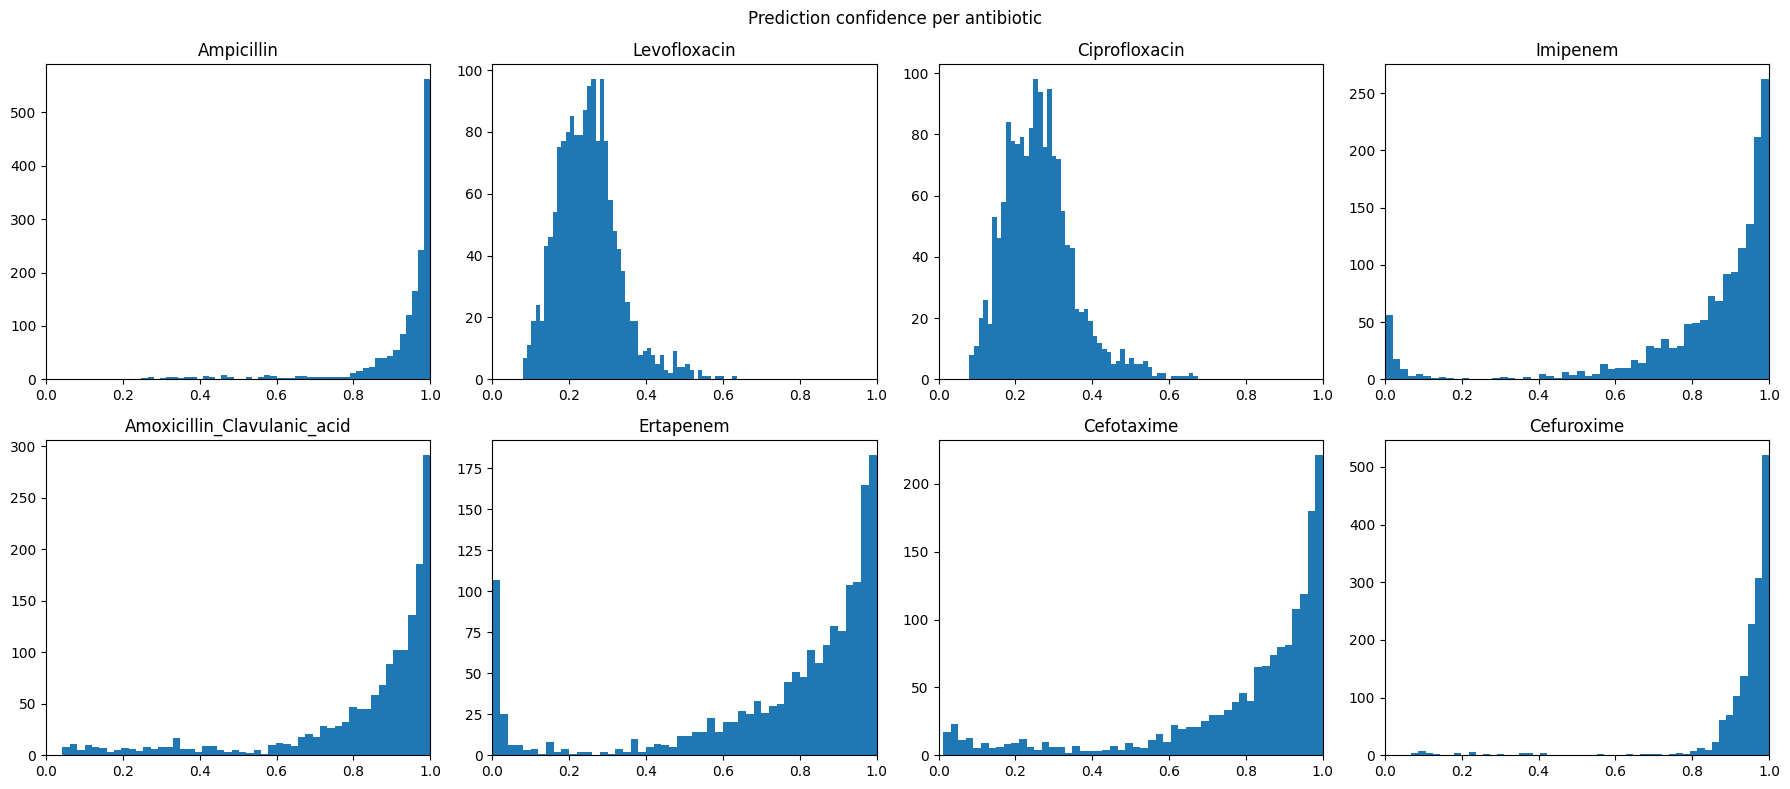

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('norm', Normalizer()),
                ('rf',
                 RandomForestClassifier(min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [10]:
# ============================================================
# 8. SEMI-SUPERVISED PSEUDO-LABELING
# ============================================================

mask_not_full = ~mask_full
X_unl = train.loc[mask_not_full, SPECTRUM_COLS]

proba_unl = np.column_stack([
    p[:, 1] for p in pipeline.predict_proba(X_unl)
])

CONF_THRESHOLD = 0.9
pseudo_mask = (proba_unl >= CONF_THRESHOLD) | (proba_unl <= 1 - CONF_THRESHOLD)

y_pseudo = train.loc[mask_not_full, ANTIBIOTICS].copy()

proba_unl = np.column_stack([
    p[:, 1] for p in pipeline.predict_proba(X_unl)
])
y_proba = proba_unl.copy()


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, ab in enumerate(ANTIBIOTICS):
    axes[i].hist(y_proba[:, i], bins=50)
    axes[i].set_title(ab)
    axes[i].set_xlim(0, 1)

plt.suptitle("Prediction confidence per antibiotic")
plt.tight_layout()
plt.show()

threshold = 0.5

for i, ab in enumerate(ANTIBIOTICS):
    labels_i = (y_proba[:, i] >= threshold).astype(float)
    mask_i = pseudo_mask[:, i]

    y_pseudo.loc[mask_i, ab] = labels_i[mask_i]


X_aug = pd.concat([X_full, X_unl])
y_aug = pd.concat([train.loc[mask_full, ANTIBIOTICS], y_pseudo]).astype(float)

mask_valid = y_aug.notna().all(axis=1)
pipeline.fit(X_aug.loc[mask_valid], y_aug.loc[mask_valid])


In [11]:
# ============================================================
# 9. SPECIES-SPECIFIC MODELS
# ============================================================

models_by_species = {}

for sp in train[SPECIES_COL].unique():
    sp_mask = (train[SPECIES_COL] == sp) & mask_full
    if sp_mask.sum() < 50:
        continue

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("norm", Normalizer()),
        ("rf", RandomForestClassifier(
            n_estimators=200,
            n_jobs=-1,
            random_state=42
        ))
    ])

    model.fit(
        train.loc[sp_mask, SPECTRUM_COLS],
        train.loc[sp_mask, ANTIBIOTICS]
    )

    models_by_species[sp] = model


In [12]:
# ============================================================
# 10. TEST PREDICTION + SUBMISSION
# ============================================================

test_proba = np.zeros((len(test), len(ANTIBIOTICS)))

for i, row in test.iterrows():
    model = models_by_species.get(row[SPECIES_COL], pipeline)

    X_row = row[SPECTRUM_COLS].to_frame().T  # evita warning
    probas = model.predict_proba(X_row)

    row_proba = []
    for pi in probas:
        if pi.shape[1] == 2:
            row_proba.append(pi[0, 1])
        else:
            # solo una clase conocida
            row_proba.append(pi[0, 0])

    test_proba[i] = row_proba


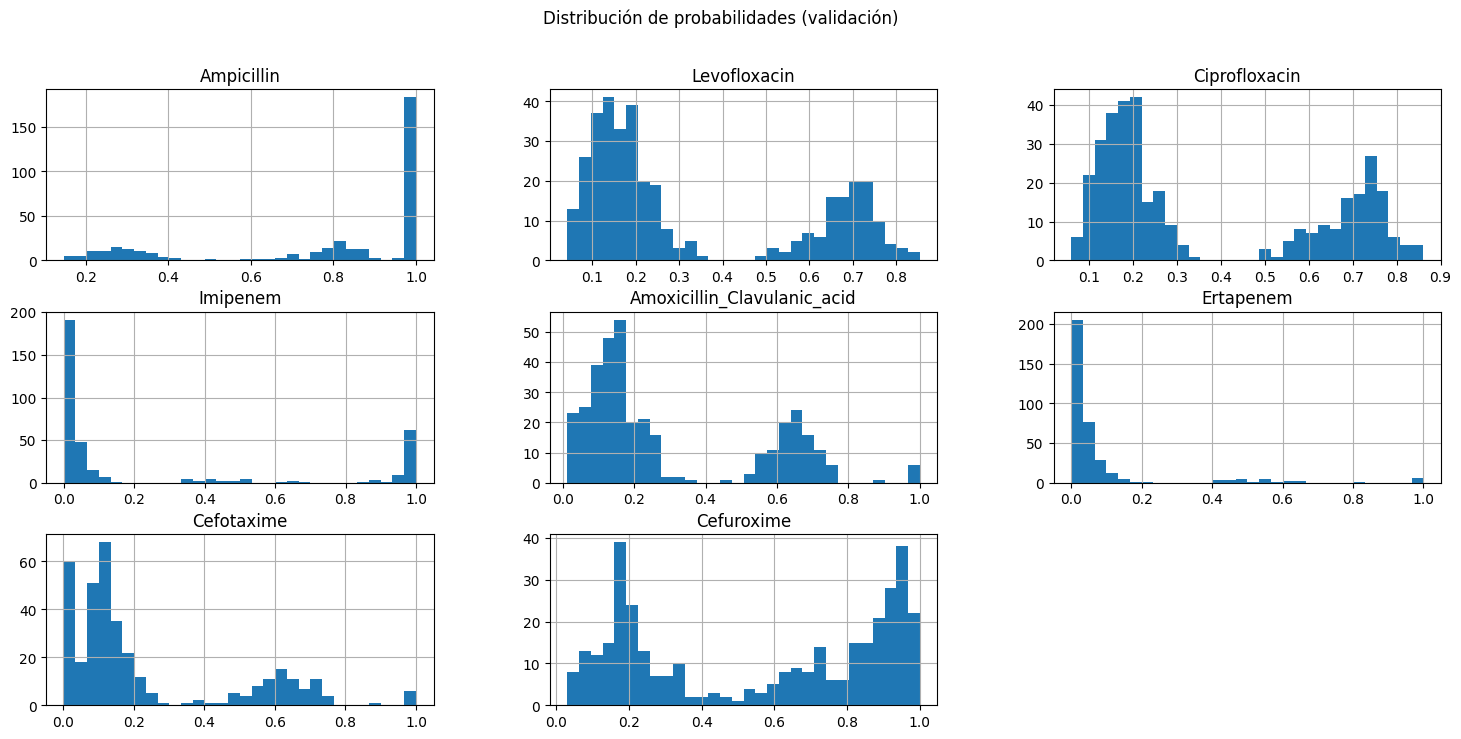

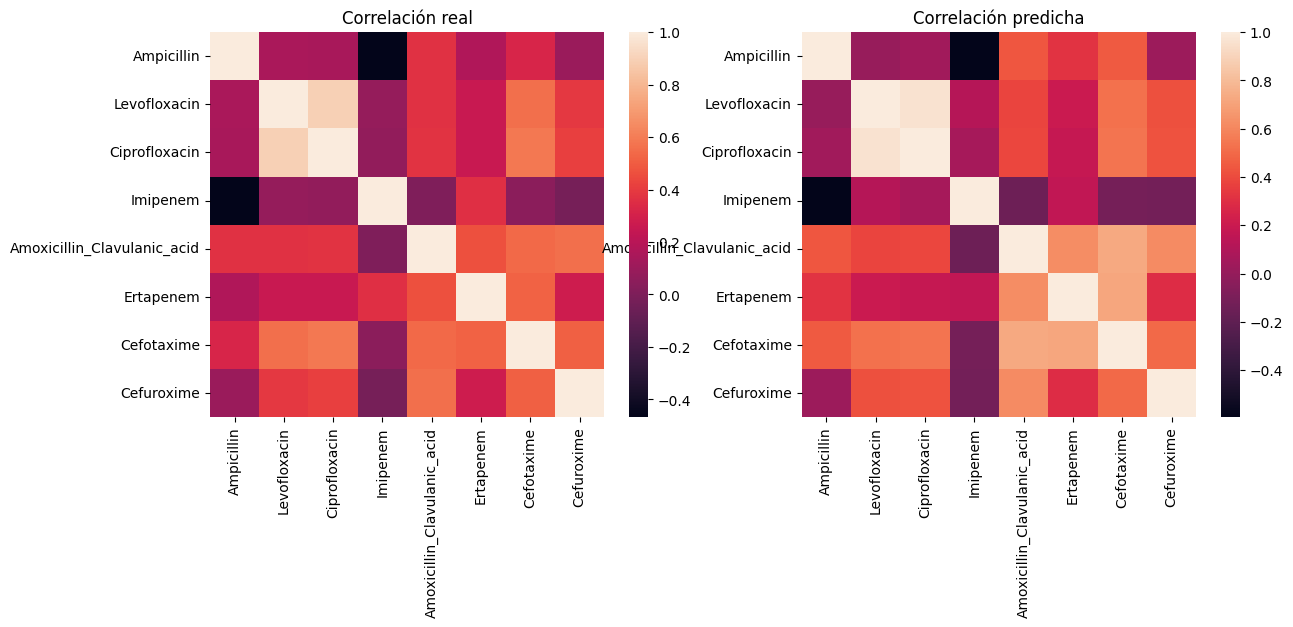

In [13]:
# ============================================================
# 11. DIAGNOSTIC PLOTS (OPTIONAL, PRE-SUBMISSION)
# ============================================================

val_proba = np.column_stack([
    p[:, 1] for p in pipeline.predict_proba(X_val)
])

val_proba_df = pd.DataFrame(val_proba, columns=ANTIBIOTICS)

val_proba_df.hist(bins=30, figsize=(18, 8))
plt.suptitle("Distribución de probabilidades (validación)")
plt.show()

corr_true = pd.DataFrame(y_val, columns=ANTIBIOTICS).corr()
corr_pred = val_proba_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_true, ax=axes[0])
axes[0].set_title("Correlación real")

sns.heatmap(corr_pred, ax=axes[1])
axes[1].set_title("Correlación predicha")
plt.show()


In [14]:
# ============================================================
# 12. CREATE SUBMISSION FILE
# ============================================================

submission = pd.DataFrame(
    test_proba,
    columns=ANTIBIOTICS
)

submission.insert(0, ID_COL, test[ID_COL].values)

# sanity checks
assert submission.shape[0] == test.shape[0]
assert list(submission.columns) == [ID_COL] + ANTIBIOTICS
assert submission.isna().sum().sum() == 0

submission.head()


,sample_id,Ampicillin,Levofloxacin,Ciprofloxacin,Imipenem,Amoxicillin_Clavulanic_acid,Ertapenem,Cefotaxime,Cefuroxime
0,SAMPLE_03360,1.000,0.165,0.230,0.035,0.135,0.050,0.235,0.295
1,SAMPLE_03361,0.260,0.220,0.230,0.970,0.040,1.000,0.030,0.280
2,SAMPLE_03362,0.735,0.490,0.555,0.010,0.475,0.040,0.250,0.735
3,SAMPLE_03363,0.250,0.285,0.290,0.925,0.055,1.000,0.015,0.065
4,SAMPLE_03364,0.660,0.555,0.615,0.005,0.375,0.025,0.365,0.840


In [15]:
submission.to_csv("submission.csv", index=False)
print("submission.csv guardado correctamente")


submission.csv guardado correctamente


In [16]:
sample = pd.read_csv(
    "/kaggle/input/antimicrobial-resistance-prediction-from-maldi-tof/sample_submission.csv"
)

print(sample.columns)
print(submission.columns)


Index(['sample_id', 'Ampicillin', 'Levofloxacin', 'Ciprofloxacin', 'Imipenem',
       'Amoxicillin_Clavulanic_acid', 'Ertapenem', 'Cefotaxime', 'Cefuroxime'],
      dtype='object')
Index(['sample_id', 'Ampicillin', 'Levofloxacin', 'Ciprofloxacin', 'Imipenem',
       'Amoxicillin_Clavulanic_acid', 'Ertapenem', 'Cefotaxime', 'Cefuroxime'],
      dtype='object')
